<a href="https://colab.research.google.com/github/ancestor9/Introduction-to-BigData-Analysis/blob/main/14%EC%A3%BC%EC%B0%A8/Deep_Learning_FNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Deep Learning algorithm & model**

<img src ='https://upload.wikimedia.org/wikipedia/commons/thumb/1/10/Blausen_0657_MultipolarNeuron.png/960px-Blausen_0657_MultipolarNeuron.png' width=500 height=300>

## **<font color='orange'> A. 활성화 함수 - 비선형 함수(Nonlinear function)**
<img src='https://media.geeksforgeeks.org/wp-content/uploads/20190410161828/newContent12.png'>

In [ ]:
import numpy as np # 넘파이 사용
import matplotlib.pyplot as plt # 맷플롯립 사용
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

<img src='https://www.analytixlabs.co.in/wp-content/uploads/2023/08/Types-of-activation-function.jpg'>

## 1. 계단 함수(Step function)


Text(0.5, 1.0, 'Step Function')

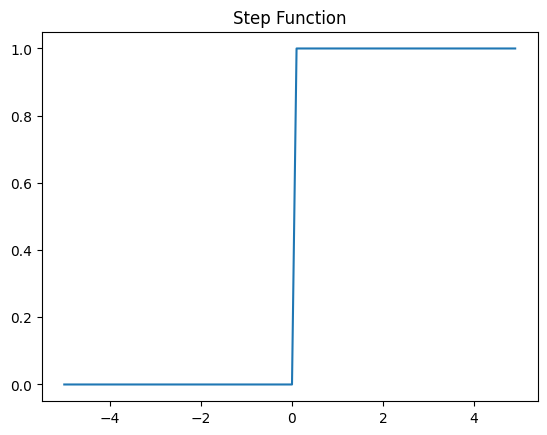

In [ ]:
def step(x):
    return np.array(x > 0, dtype=int)

x = np.arange(-5.0, 5.0, 0.1) # -5.0부터 5.0까지 0.1 간격 생성
y = step(x)
plt.title('Step Function')
plt.plot(x,y)
plt.show()

In [ ]:
np.array(np.arange(-5.0, 5.0, 0.1) > 0, dtype= int)

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

## 2. 시그모이드 함수(Sigmoid function)와 기울기 소실

시그모이드 함수의 출력값이 0 또는 1에 가까워지면, 그래프의 기울기가 완만해져 그 값은 0에 가까워지는데 역전파 과정에서 0에 가까운 아주 작은 기울기가 곱해지게 되면, 앞단에는 기울기가 잘 전달되지 않게 되는 현상을 기울기 소실(Vanishing Gradient) 문제

Text(0.5, 1.0, 'Sigmoid Function')

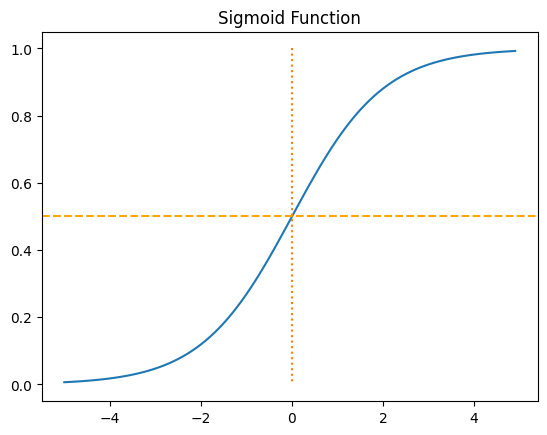

In [ ]:
def sigmoid(x):
    return 1/(1+np.exp(-x))

x = np.arange(-5.0, 5.0, 0.1)
y = sigmoid(x)

plt.plot(x, y)
plt.plot([0,0],[1.0,0.0], ':') # 가운데 점선 추가
plt.axhline(y=0.5, color='orange', linestyle='--')
plt.title('Sigmoid Function')
plt.show()

## 3. 하이퍼볼릭탄젠트 함수(Hyperbolic tangent function)

하이퍼볼릭탄젠트 함수의 경우에는 시그모이드 함수와는 달리 0을 중심으로 하고 있는데, 이때문에 시그모이드 함수와 비교하면 반환값의 변화폭이 더 커서 시그모이드 함수보다는 기울기 소실 증상이 적은 편이라 은닉층에서 시그모이드 함수보다는 많이 사용

Text(0.5, 1.0, 'Tanh Function')

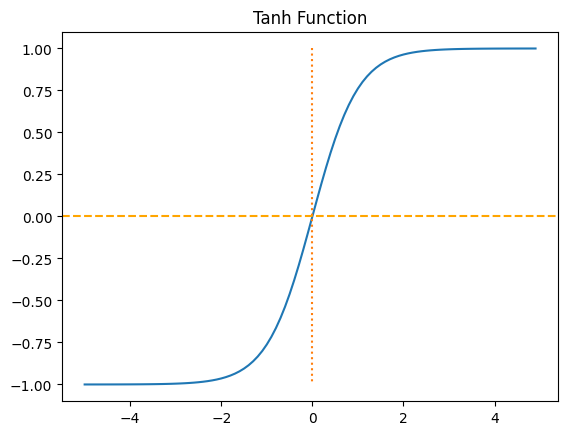

In [ ]:
x = np.arange(-5.0, 5.0, 0.1) # -5.0부터 5.0까지 0.1 간격 생성
y = np.tanh(x)

plt.plot(x, y)
plt.plot([0,0],[1.0,-1.0], ':')
plt.axhline(y=0, color='orange', linestyle='--')
plt.title('Tanh Function')
plt.show()

## 4. 렐루 함수(ReLU)

렐루 함수는 음수를 입력하면 0을 출력하고, 양수를 입력하면 입력값을 그대로 반환하게 되어 렐루 함수는 특정 양수값에 수렴하지 않으므로 깊은 신경망에서 시그모이드 함수보다 훨씬 더 잘 작동
렐루 함수는 시그모이드 함수와 하이퍼볼릭탄젠트 함수와 같이 어떤 연산이 필요한 것이 아니라 단순 임계값이므로 연산 속도도 빠르나 여전히 문제점이 존재하는데, 입력값이 음수면 기울기도 0이 되어 이 뉴런은 다시 회생하는 것이 매우 어렵워 이 문제를 죽은 렐루(dying ReLU)라 함

Text(0.5, 1.0, 'Relu Function')

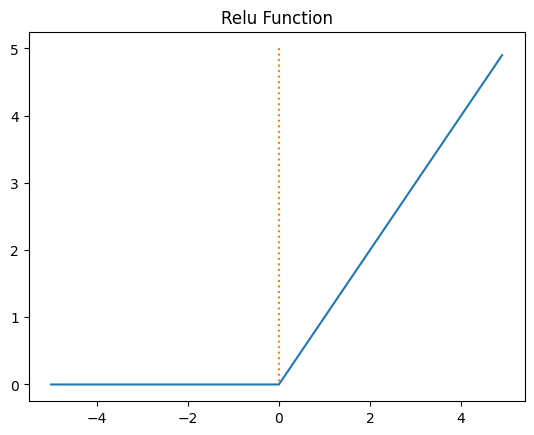

In [ ]:
def relu(x):
    return np.maximum(0, x)

x = np.arange(-5.0, 5.0, 0.1)
y = relu(x)

plt.plot(x, y)
plt.plot([0,0],[5.0,0.0], ':')
plt.title('Relu Function')
plt.show()

## 5. 리키 렐루(Leaky ReLU)
죽은 렐루를 보완하기 위해 ReLU의 변형 함수들이 등장하기 시작했습니다. 변형 함수는 여러 개가 있지만 Leaky ReLU는 입력값이 음수일 경우에 0이 아니라 0.001과 같은 매우 작은 수를 반환

Text(0.5, 1.0, 'Leaky ReLU Function')

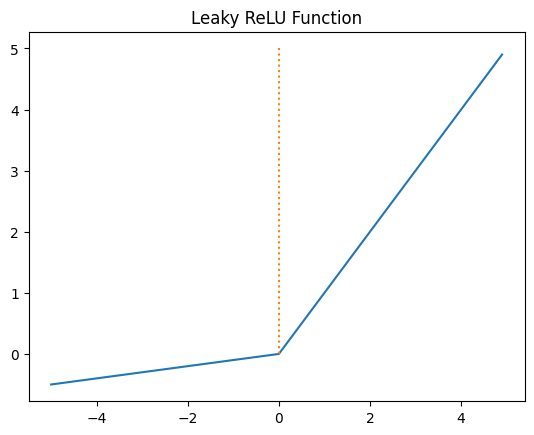

In [ ]:
a = 0.1

def leaky_relu(x):
    return np.maximum(a*x, x)

x = np.arange(-5.0, 5.0, 0.1)
y = leaky_relu(x)

plt.plot(x, y)
plt.plot([0,0],[5.0,0.0], ':')
plt.title('Leaky ReLU Function')
plt.show()

## 6. 소프트맥스 함수(Softamx function)
은닉층에서 ReLU(또는 ReLU 변형) 함수들을 사용하는 것이 일반적이지만 분류 문제를 로지스틱 회귀와 소프트맥스 회귀를 출력층에 적용하여 사용합니다.

소프트맥스 함수는 시그모이드 함수처럼 출력층의 뉴런에서 주로 사용되는데, 시그모이드 함수가 두 가지 선택지 중 하나를 고르는 이진 분류 (Binary Classification) 문제에 사용된다면 세 가지 이상의 (상호 배타적인) 선택지 중 하나를 고르는 다중 클래스 분류(MultiClass Classification) 문제에 주로 사용

Text(0.5, 1.0, 'Softmax Function')

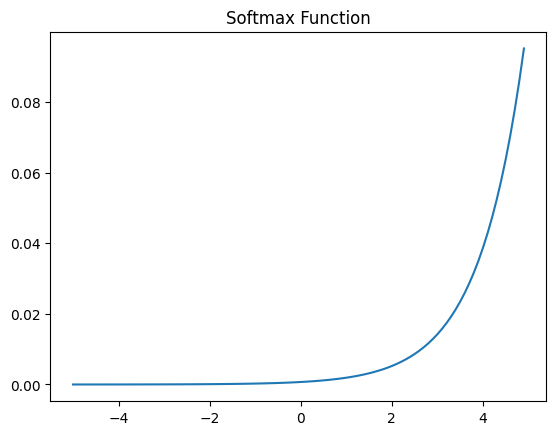

In [ ]:
x = np.arange(-5.0, 5.0, 0.1) # -5.0부터 5.0까지 0.1 간격 생성
y = np.exp(x) / np.sum(np.exp(x))

plt.plot(x, y)
plt.title('Softmax Function')
plt.show()

# **[Deeplearning Playground](https://playground.tensorflow.org/#activation=tanh&batchSize=10&dataset=circle&regDataset=reg-plane&learningRate=0.03&regularizationRate=0&noise=0&networkShape=4,2&seed=0.17186&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false)**

## **<font color='orange'> B. Regression and Neural network**
### 데이터 생성

In [ ]:
x_train= np.random.random((1000,1))
np.mean(x_train), np.std(x_train)
y_train = x_train*2 + np.random.random((1000,1))/3.0
np.mean(y_train), np.std(y_train)

x_test= np.random.random((100,1))
y_test = x_test*2 + np.random.random((100,1))/3.0

(np.float64(0.4881581696735925), np.float64(0.29003894475784614))

(np.float64(1.1422765714026153), np.float64(0.5897992416754256))

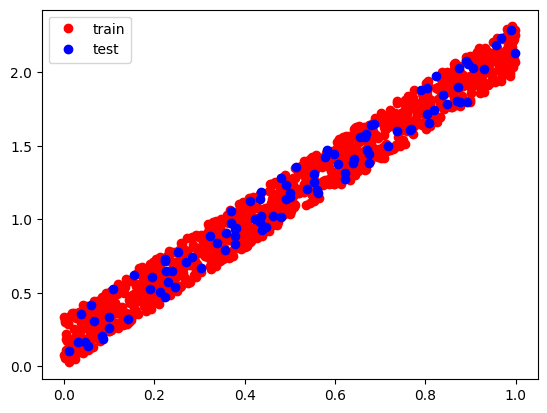

In [ ]:
plt.plot(x_train, y_train, 'ro')
plt.plot(x_test, y_test, 'bo')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# 1. Scikit-learn API의 linear regression

In [ ]:
from sklearn import linear_model
from sklearn.metrics import mean_squared_error

# 모델구성하기
model = linear_model.LinearRegression()

# 학습하고 예측
y_pred = model.fit(x_train, y_train).predict(x_test)

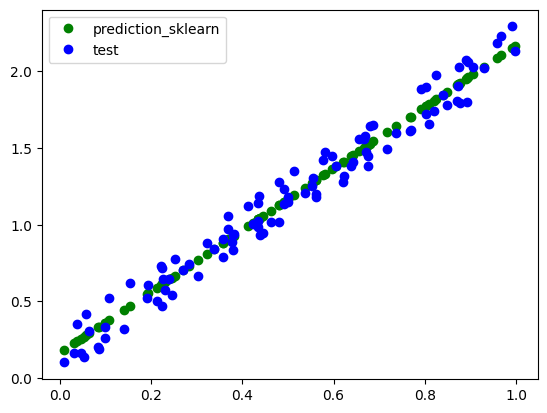

절편: [0.16295444], 기울기:[[2.00615742]], mse: 0.008890690263938185


In [ ]:
plt.plot(x_test, y_pred, 'go')
plt.plot(x_test, y_test, 'bo')
plt.legend(['prediction_sklearn', 'test'], loc='upper left')
plt.show()

# 파라미터 추정과 평가
print(f'절편: {model.intercept_}, 기울기:{model.coef_}, mse: {mean_squared_error(y_test, y_pred)}')

In [ ]:
MSEs = [mean_squared_error(y_test, y_pred)]
MSEs

[0.008890690263938185]

# 2. 퍼셉트론 신경망
<img src='https://aiml.com/wp-content/uploads/2023/09/perceptron-a-neuron-2.png'>

In [ ]:
from keras.models import Sequential
from keras.layers import Dense

In [ ]:
x_train.shape

(1000, 1)

입력변수가 1d tensor

In [ ]:
# 모델구성
model = Sequential()
model.add(Dense(1, input_dim=1))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Parameters (weight, bias)
- The # of weights : {입력행렬 차원(1차원) x layer1 뉴런수(1 nodes)} = 1
- The # of bias : layer1 뉴런 수(1 nodes) = 1
- 추정할 파라미터 개수는 1+1 = 2

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 학습하기
model.compile(optimizer='rmsprop', loss='mse')
hist = model.fit(x_train, y_train, epochs=50, batch_size=64) # epoch을 증가시켜보기

Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 0.8541
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7838  
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7490 
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7467 
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7131 
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.6647
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6287 
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5917
Epoch 9/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.5503 
Epoch 10/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.5305
Epoch 11/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4862 
Epoch 12/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4752
Epoch 13/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4529 
Epoch 14/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.4057 
Epoch 15/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3780 
Epoch 1

In [ ]:
w, b = model.get_weights()
print(f'절편: {b}, 기울기:{w}')

절편: [0.48708543], 기울기:[[1.3704984]]


In [ ]:
y_pred_perceptron = b + w*x_test

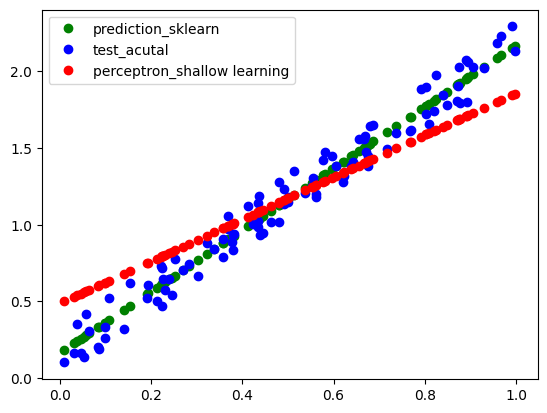

In [ ]:
plt.plot(x_test, y_pred, 'go')
plt.plot(x_test, y_test, 'bo')
plt.plot(x_test, y_pred_perceptron, 'ro')
plt.legend(['prediction_sklearn', 'test_acutal', 'perceptron_shallow learning'], loc='upper left')
plt.show()

### <font color ='red'> epoch을 200으로 증가시키면 예측을 잘한다. 200 epoch을 훈련후 다시 그려보기

dict_keys(['loss'])

Text(0.5, 0, 'epoch')

Text(0, 0.5, 'MSE')

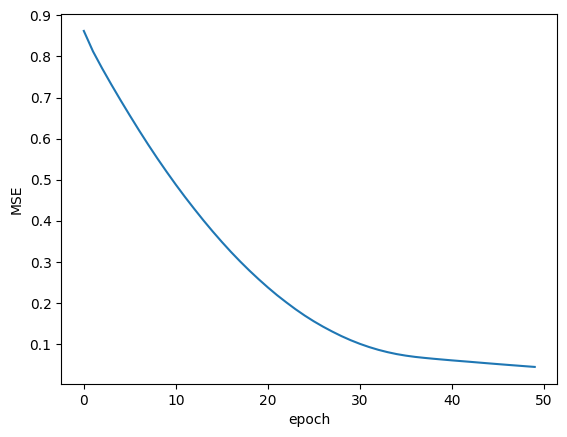

In [ ]:
# 학습과정 확인하기
hist.history.keys()
plt.plot(hist.history['loss'])
plt.xlabel('epoch'); plt.ylabel('MSE')

In [ ]:
# 모델 평가
loss = model.evaluate(x_test, y_test, batch_size=30)
print(f'mse: {loss}')

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0433
mse: 0.04204373434185982


In [ ]:
MSEs.append(loss)
MSEs

[0.008890690263938185, 0.04204373434185982]

# 3. FNNM(Forward Neural Network Model) with one hidden layer
## Shallow learning model
https://keras.io/api/models/

In [1]:
! pip install mglearn --quiet

import mglearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 10.6 MB/s eta 0:00:00


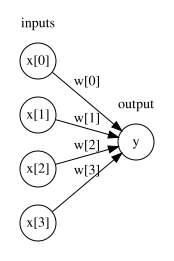

In [2]:
mglearn.plots.plot_logistic_regression_graph()

### <font color = 'orange'> Regression
### <font color = 'orange'>  회귀예측이기 때문에 최종 layer에는 1개로 activation 함수없이 구현

In [ ]:
# 모델구성
model = Sequential()
model.add(Dense(10, input_dim=1, activation='relu', name="layer1"))  # Try Hidden layer의 노드(뉴런) 개수 증감
model.add(Dense(1, name="layer2"))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Parameters (weight, bias)
- The # of weights : {입력행렬 차원(1차원) x layer1 뉴런수(10 nodes)} + {layer1 (노두수(10 nodes) x layer2 노드수(1 node))} = (1x10) + (10) = 20
- The # of bias : layer1 뉴런 수(10 nodes) + layer2 뉴런수(1 nodes) = 10+1 = 11
- 추정할 파라미터 개수는 20+11 = 31

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                  │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Dense)                  │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 학습하기
model.compile(optimizer='rmsprop', loss='mse')
hist = model.fit(x_train, y_train, epochs=50, batch_size=64, verbose= 0) # epoch을 증가시켜보기

In [ ]:
# 노드(뉴런) 개수만큼 weight(b, w)가 생성
model.get_weights()

[array([[ 0.08971091, -0.61585724,  0.6992649 , -0.34541616,  0.22809504,
          0.8523934 ,  0.95735663,  0.21545799,  0.81519973,  0.35527253]],
       dtype=float32),
 array([-0.08965318,  0.        ,  0.08862028,  0.        , -0.2287173 ,
        -0.09373096,  0.11131258, -0.21528918, -0.04949882, -0.35518724],
       dtype=float32),
 array([[-0.6059526 ],
        [ 0.14741206],
        [ 0.8948091 ],
        [-0.4858613 ],
        [-0.46596307],
        [ 0.44105008],
        [ 0.582096  ],
        [-0.27477226],
        [ 0.55427444],
        [-0.3659671 ]], dtype=float32),
 array([0.08339852], dtype=float32)]

In [ ]:
y_pred_one_hidden_layer = model.predict(x_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


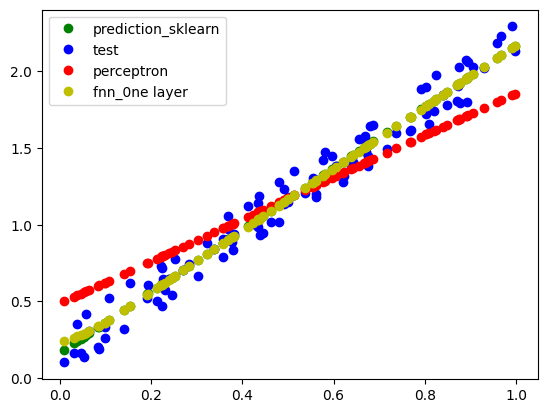

In [ ]:
plt.plot(x_test, y_pred, 'go')
plt.plot(x_test, y_test, 'bo')
plt.plot(x_test, y_pred_perceptron, 'ro')
plt.plot(x_test, y_pred_one_hidden_layer, 'yo')
plt.legend(['prediction_sklearn', 'test', 'perceptron', 'fnn_0ne layer'], loc='upper left')
plt.show()

In [ ]:
# 모델 평가
loss = model.evaluate(x_test, y_test, batch_size=30)
print(f'mse: {loss}')

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.0096
mse: 0.009134417399764061


In [ ]:
MSEs.append(loss)
MSEs

[0.008890690263938185, 0.04204373434185982, 0.009134417399764061]

dict_keys(['loss'])

Text(0.5, 0, 'epoch')

Text(0, 0.5, 'MSE')

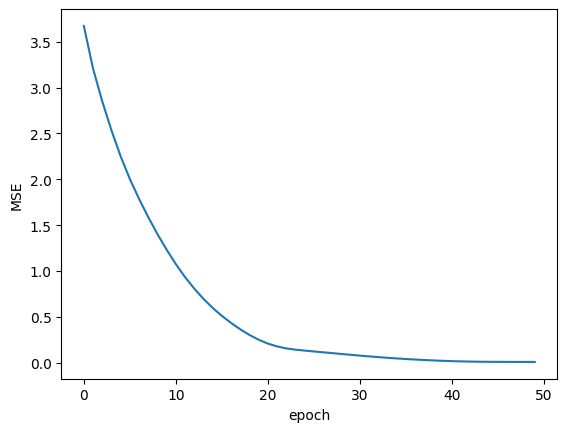

In [ ]:
# 학습과정 확인하기
hist.history.keys()
plt.plot(hist.history['loss'])
plt.xlabel('epoch'); plt.ylabel('MSE')

# 4. FNNM(Forward Neural Network Model) with two hidden layer
## Deep learning model
Hidden layer를 추가할 수록 예측 성능은 높아지게 됨

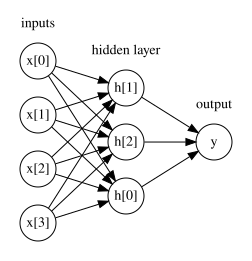

In [5]:
mglearn.plots.plot_single_hidden_layer_graph()

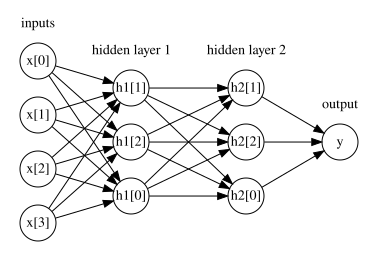

In [3]:
mglearn.plots.plot_two_hidden_layer_graph()

In [ ]:
# 모델구성
model = Sequential()
model.add(Dense(10, input_dim=1, activation='relu', name="layer1"))
model.add(Dense(10, activation='relu', name="layer2"))
model.add(Dense(1, name="layer3"))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                  │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Dense)                  │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer3 (Dense)                  │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 141 (564.00 B)

 Trainable params: 141 (564.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 학습하기
model.compile(optimizer='rmsprop', loss='mse')
hist = model.fit(x_train, y_train, epochs=50, batch_size=64, verbose= 0)

In [ ]:
y_pred_two_hidden_layer = model.predict(x_test)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


In [ ]:
# 모델 평가
loss = model.evaluate(x_test, y_test, batch_size=30)
print(f'mse: {loss}')

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.0094
mse: 0.008888741955161095


In [ ]:
MSEs.append(loss)
MSEs

[0.008890690263938185,
 0.04204373434185982,
 0.009134417399764061,
 0.008888741955161095]

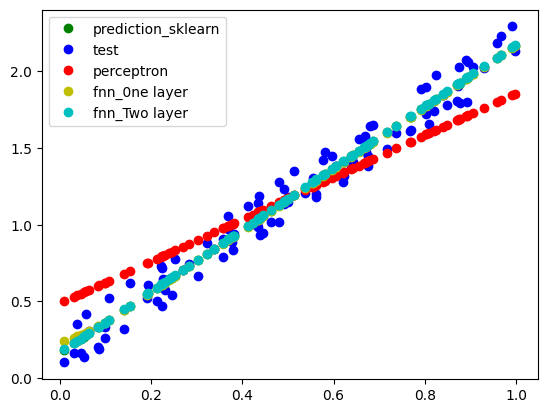

In [ ]:
plt.plot(x_test, y_pred, 'go')
plt.plot(x_test, y_test, 'bo')
plt.plot(x_test, y_pred_perceptron, 'ro')
plt.plot(x_test, y_pred_one_hidden_layer, 'yo')
plt.plot(x_test, y_pred_two_hidden_layer, 'co')
plt.legend(['prediction_sklearn', 'test', 'perceptron', 'fnn_0ne layer', 'fnn_Two layer'], loc='upper left')
plt.show()

dict_keys(['loss'])

Text(0.5, 0, 'epoch')

Text(0, 0.5, 'MSE')

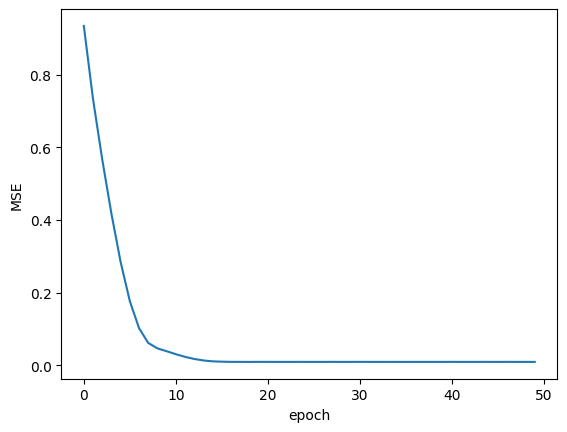

In [ ]:
# 학습과정 확인하기
hist.history.keys()
plt.plot(hist.history['loss'])
plt.xlabel('epoch'); plt.ylabel('MSE')

# <font color='orange'> C. Binary Classification : 실습 diabetes dataset

### 1. Loading the diabets dataset in Keras

In [ ]:
# prompt: diabetes 데이터 로딩

from sklearn.model_selection import train_test_split
from sklearn.datasets import load_diabetes

# 데이터 로딩
diabetes = load_diabetes()
diabetes

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]]),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142., 155., 225.,  59

In [ ]:
# prompt: diabetes 데이터프레임으로 변경

import pandas as pd

# 데이터프레임으로 변경
diabetes_df = pd.DataFrame(data=diabetes.data, columns=diabetes.feature_names)
diabetes_df['target'] = diabetes.target
diabetes_df


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0
...,...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207,178.0
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485,104.0
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491,132.0
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930,220.0


### 2. 데이터셋 생성하기

In [ ]:
# 특성(features)과 타겟(target) 분리
X = diabetes.data
y = diabetes.target

# Convert the continuous target to binary based on a threshold (e.g., median)
threshold = np.median(y) # Using the median as a threshold
y_binary = (y > threshold).astype(int)

# 데이터 확인
print("데이터셋 형태:", X.shape, y_binary.shape)
print("이진 타겟 변수 값 분포:", np.bincount(y_binary))

데이터셋 형태: (442, 10) (442,)
이진 타겟 변수 값 분포: [221 221]


### 3. 모델 구성하기
### <font color = 'orange'> Multicalss Classification
### <font color = 'orange'> 입력변수 8개를 받아 2개 hidden을 만들고 마지막 레이어는 sigmoid 활성화함수로 모델 구현

In [ ]:
model = Sequential()
model.add(Dense(12, input_dim=10, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### 4. 모델 학습과정 설정하기

In [ ]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

### 5. 모델 학습시키기

In [ ]:
model.fit(X, y_binary, epochs=50, batch_size=20)

Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.5296 - loss: 0.6899
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6515 - loss: 0.6827 
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6730 - loss: 0.6801 
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6585 - loss: 0.6705
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6766 - loss: 0.6611 
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7096 - loss: 0.6450 
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7147 - loss: 0.6310 
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7297 - loss: 0.6193 
Epoch 9/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7407 - loss: 0.6106 
Epoch 10/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6778 - loss: 0.6141 
Epoch 11/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7295 - loss: 0.5960 
Epoch 12/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0

# <font color='red'> D. Multiclass Classification : 실습 The MNIST dataset in Keras

### 1.Loading the MNIST dataset in Keras

In [ ]:
from keras.datasets import mnist
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

In [ ]:
train_images.shape
len(train_labels)
test_images.shape
len(test_labels)
test_labels

(60000, 28, 28)

60000

(10000, 28, 28)

10000

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

### 2. The network architecture

### <font color = 'orange'> Multicalss Classification
### <font color = 'orange'> 10개를 구분하여야 하기 때문에 최종 layer에는 10개로 Softmax로 모델 구현

In [ ]:
from keras import models
from keras import layers
network = models.Sequential()
network.add(layers.Dense(512, activation='relu', input_shape=(28 * 28,)))
network.add(layers.Dense(10, activation='softmax'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### 3. The compilation step
### <font color = 'orange'> 다중분류이기 떄문에 'categorical_crossentropy'


In [ ]:
network.compile(optimizer='rmsprop',
                loss='categorical_crossentropy', metrics=['accuracy'])

4. Preparing the image data (자료표준화)

In [ ]:
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype('float32') / 255
test_images = test_images.reshape((10000, 28 * 28))
test_images = test_images.astype('float32') / 255

from keras.utils import to_categorical
train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

5. model fitting

In [ ]:
network.fit(train_images, train_labels, epochs=5, batch_size=128)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8695 - loss: 0.4521
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9650 - loss: 0.1175
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9795 - loss: 0.0706
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9855 - loss: 0.0502
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9884 - loss: 0.0371


In [ ]:
test_loss, test_acc = network.evaluate(test_images, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9758 - loss: 0.0770


In [ ]:
print('test_acc:', test_acc)

test_acc: 0.9793000221252441


# End

## **For Futther details!**
### **https://github.com/fchollet/deep-learning-with-python-notebooks**